In [ ]:
import os
import paths

os.chdir(paths.PROJECT_ROOT)

In [1]:
import utils_inverse
import utils_plotting
%load_ext autoreload
%autoreload 2

# Optimizing CO2 training emissions

Worked example of the CO2-only experiment: train a baseline emulator, then use the differentiable SCM's gradients to optimize the emissions it is trained on.

The optimization itself is expensive, so the cells below load checkpoints produced by `pipeline/04_optimization/04a_inverse_CO2_only.py`.

## 1. Generate initial parameters, test backpropagation, and create baseline emulator

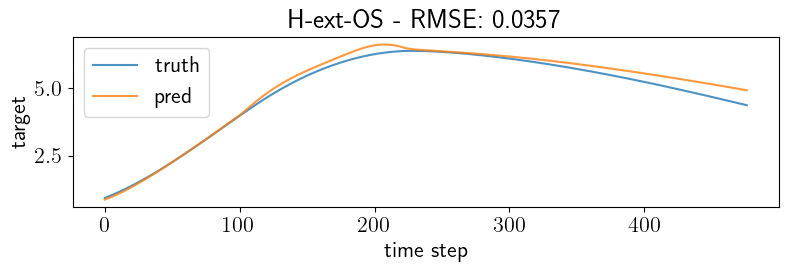

Getting gradient for historical...
	||grad BC||: 0.0
	||grad CH4||: 0.0
	||grad CO2||: 0.00019439702737145126
	||grad N2O||: 0.0
	||grad Sulfur||: 0.0


In [2]:
# Required to generate baseline parameters
agents        = ['CO2']       # Forcing agents included in the temperature simulation
active_agents = ("CO2",)      # Forcing agents with active gradients (can differ from above)
hidden_sizes  = [16]          # Dimension of neural network emulator
idx_demo      = 1             # Index of scenario to plot
test_scen     = 'historical'  # Scenario to test backpropagation; gradient printed wrt this scenario
verbose       = False         # Flag to print RMSE values for test

# Generate initial parameters and test backpropagation
params0, emis_dict_train_JAX = utils_inverse.generate_init_params_and_train_data(agents,
                                                                                 active_agents,
                                                                                 test_scen,
                                                                                 hidden_sizes=hidden_sizes,
                                                                                 idx_demo=idx_demo,
                                                                                 verbose=verbose)

In [3]:
# Generate data for emulator evaluation
(eval_sets,
emis_dict_tier1_JAX,
emis_dict_tier2_JAX,
emis_dict_DECK_JAX,
emis_dict_CS3_JAX,
emis_dict_all_JAX) = utils_inverse.generate_eval_data(agents, CS3=True, DAMIP=False, GeoMIP=False)

In [4]:
# Baseline emulator parameters
save_path   = None  # Set to a path to cache the trained baseline emulator
verbose     = False # Flag to print NRMSE values from the baseline emulator

# Independently tuned baseline hyperparameters; K matches the optimized emulator's
# K_inner. See data/SI_results/baseline_hp/k400_search/best_baseline_config_K400.json.
baseline_K, baseline_lr, baseline_weight_decay = 400, 0.04803932015937589, 0.001

# Create baseline emulator
baseline_results, baseline_pred_delT, ground_truth_delT = utils_inverse.generate_and_eval_baseline_emulator(emis_dict_tier1_JAX,
                                                                                                            eval_sets, save_path=save_path,
                                                                                                            verbose=verbose, hidden_sizes=hidden_sizes,
                                                                                                            K=baseline_K, lr=baseline_lr, weight_decay=baseline_weight_decay)

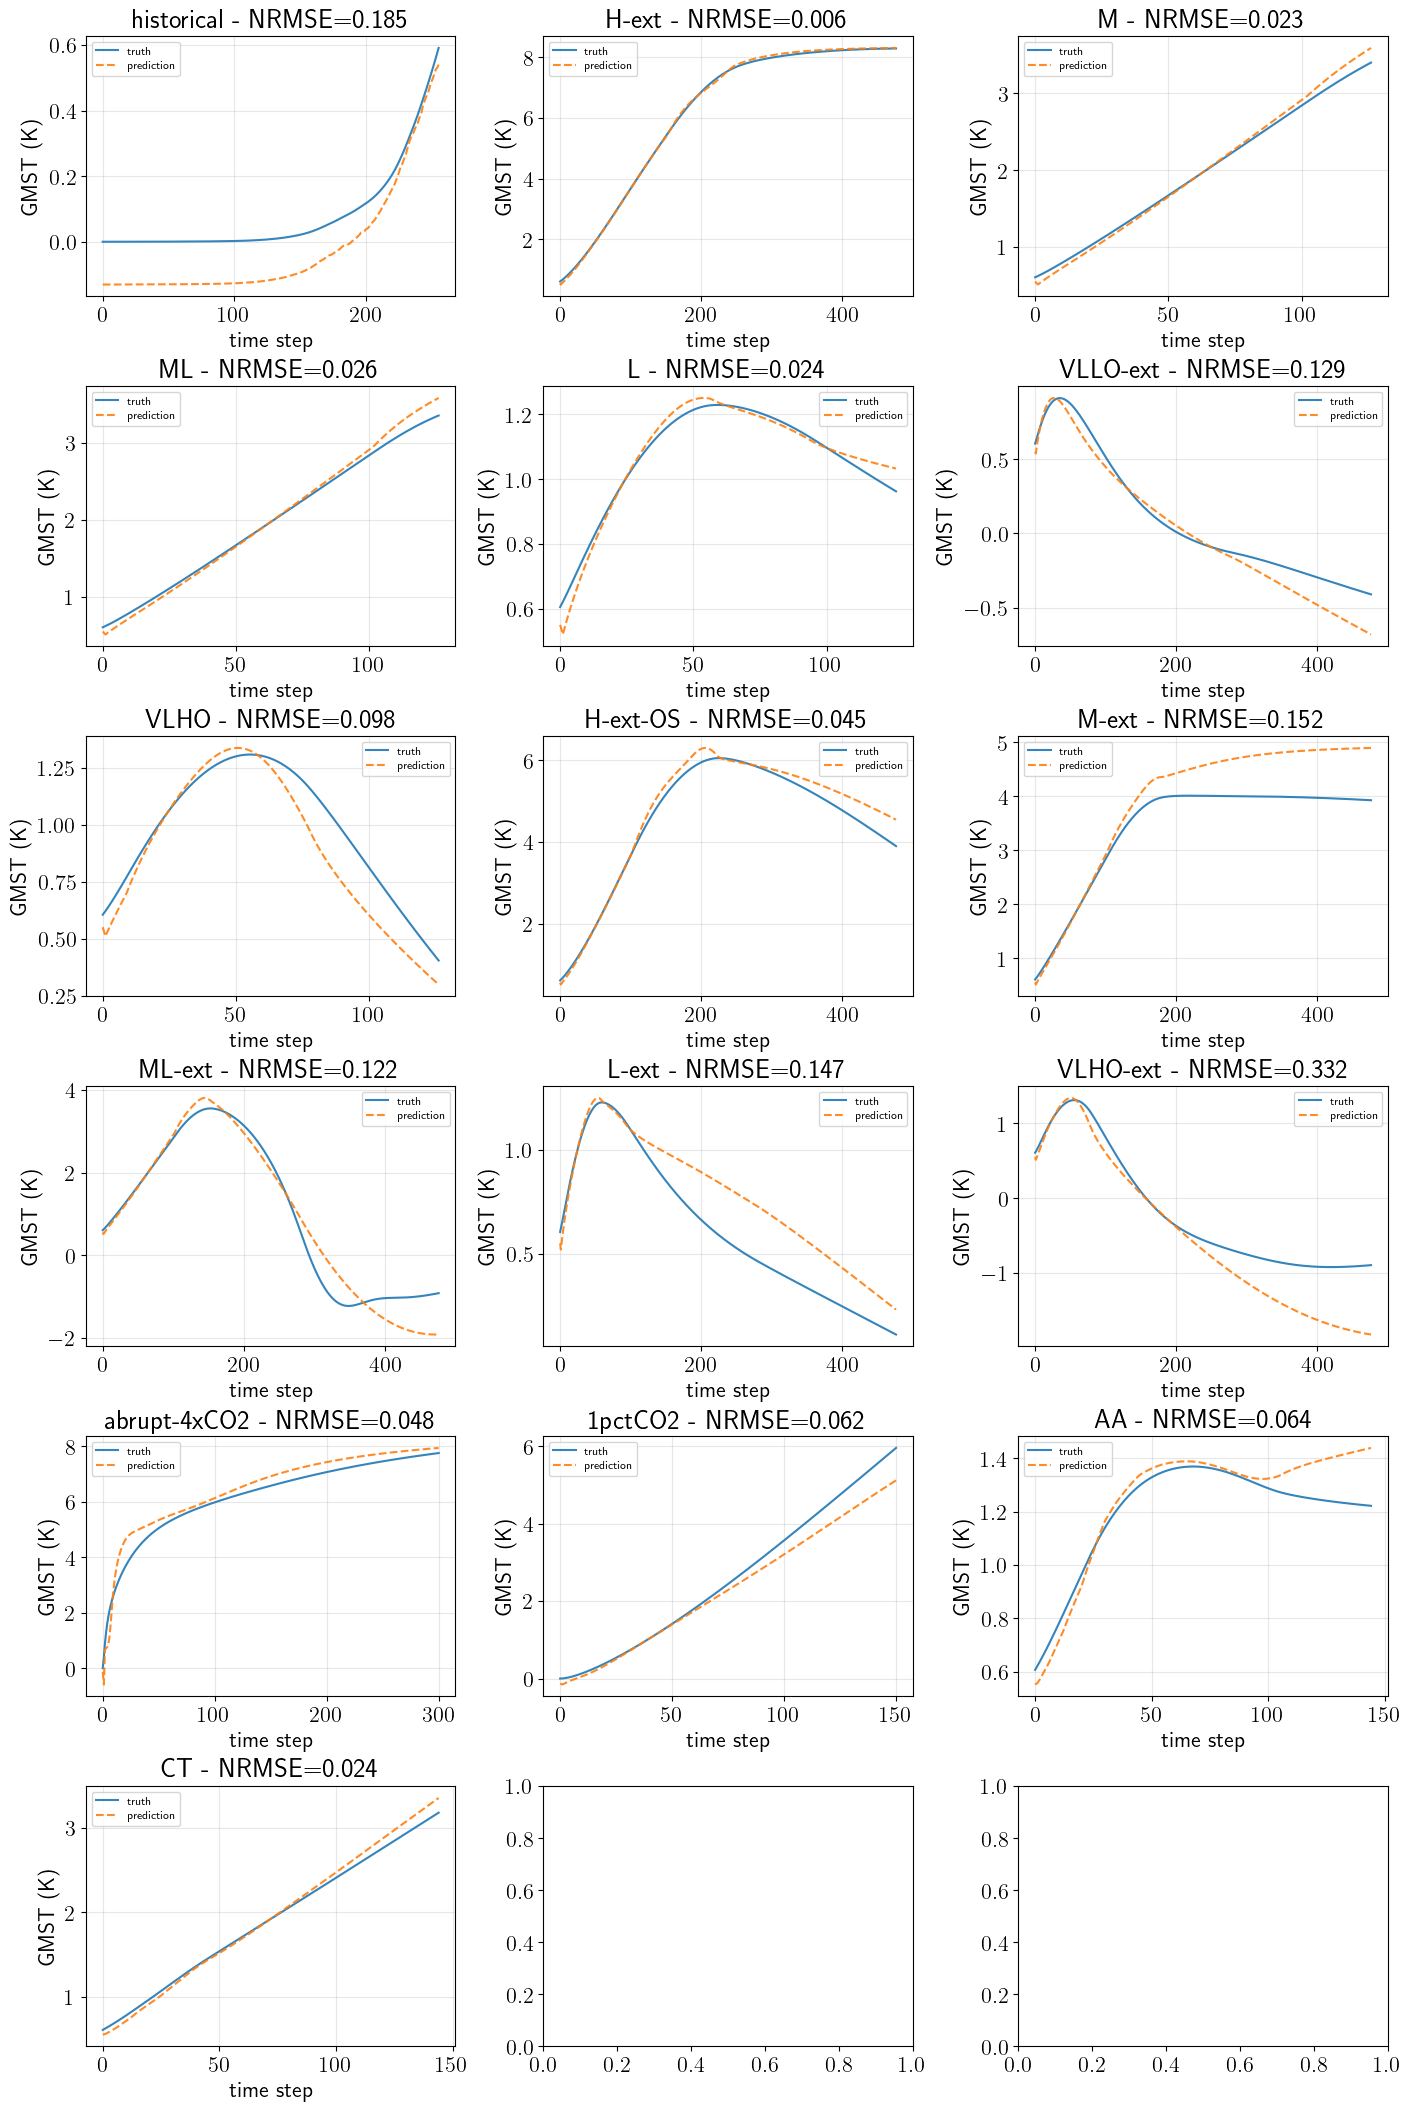

In [5]:
# Optional: plot predictions of baseline emulator
utils_plotting.plot_baseline_pred_delT(baseline_results, baseline_pred_delT, ground_truth_delT)

## 2. Optimize CO<sub>2</sub> emissions time series used in training

### 2a. Optimize for individual scenario (H-ext), starting from constant initial condition

In [ ]:
# The optimization itself runs in pipeline/04_optimization/04a_inverse_CO2_only.py
results_CO2_Hext_const = utils_inverse.load_inverse_ckpt('checkpoints/co2_retuned/inverse_sine_H-ext_co2_only.pkl')


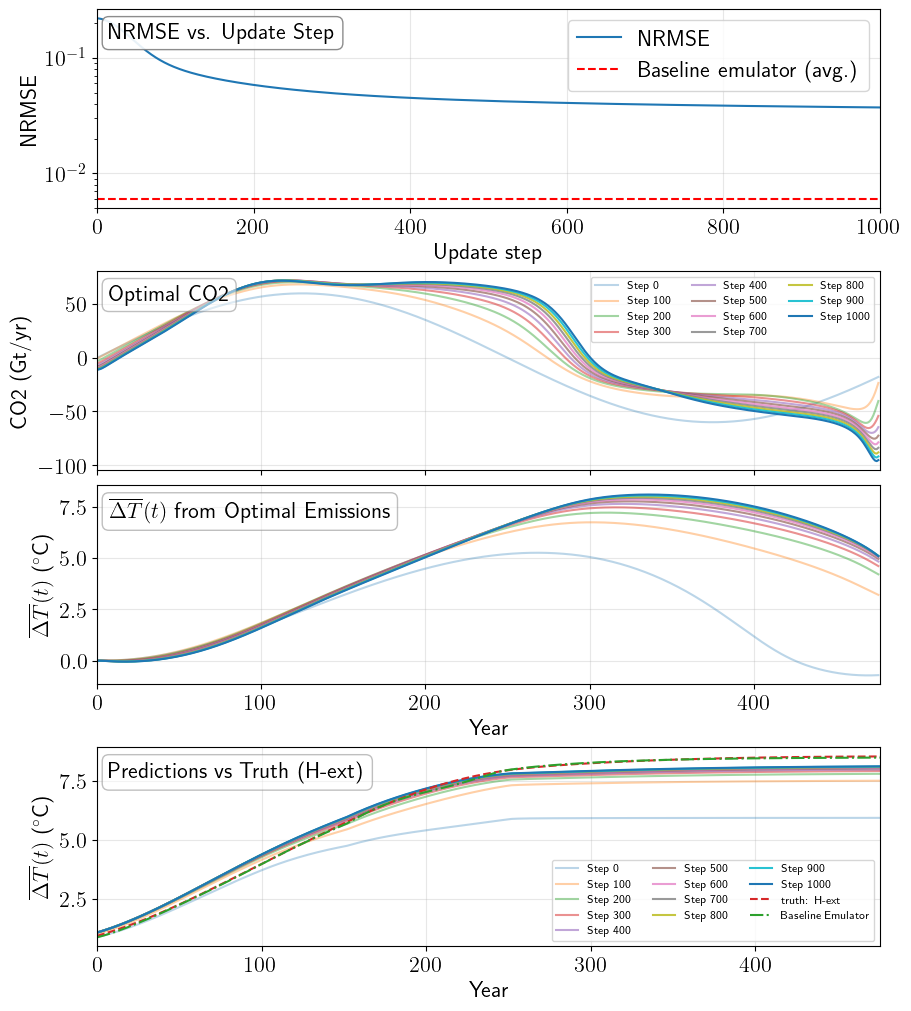

In [7]:
# Optional: plot results of optimization
predict_plot = 'H-ext'
utils_plotting.plot_inverse_results(
    results_CO2_Hext_const,
    baseline_results['Tier 1'][predict_plot],
    active_agents=active_agents,
    pred_scenario=predict_plot,
    baseline_preds=baseline_pred_delT['Tier 1'][predict_plot]
)

### 2b. Optimize training data for predictive skill over all evaluation sets

In [ ]:
# The optimization itself runs in pipeline/04_optimization/04a_inverse_CO2_only.py
results_CO2_dict = {
    'tier1': utils_inverse.load_inverse_ckpt('checkpoints/co2_retuned/inverse_constant_tier1_co2_only.pkl'),
    'tier2': utils_inverse.load_inverse_ckpt('checkpoints/co2_retuned/inverse_constant_tier2_co2_only.pkl'),
    'DECK': utils_inverse.load_inverse_ckpt('checkpoints/co2_retuned/inverse_constant_DECK_co2_only.pkl'),
    'CS3': utils_inverse.load_inverse_ckpt('checkpoints/co2_retuned/inverse_constant_CS3_co2_only.pkl'),
    'all': utils_inverse.load_inverse_ckpt('checkpoints/co2_retuned/inverse_constant_all_co2_only.pkl')
}


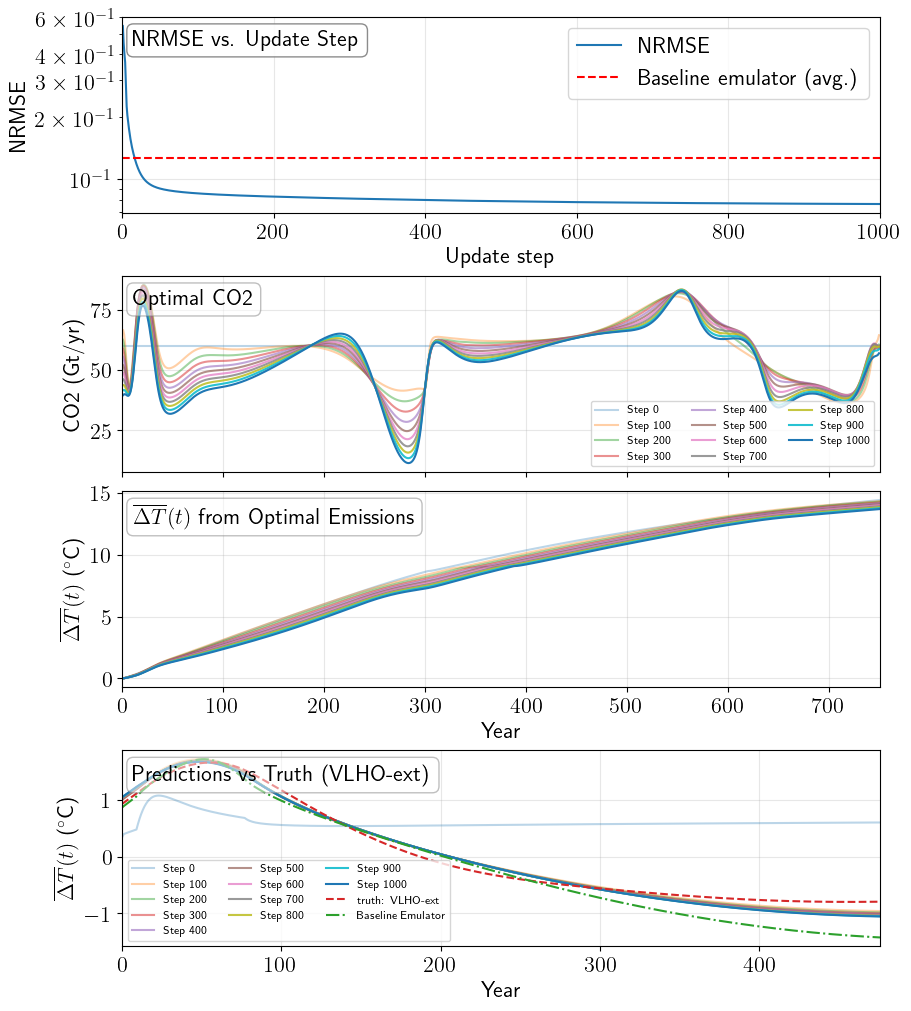

In [9]:
# Optional: plot results of optimization
## Plotting parameters
opt_test        = 'tier2'  # Evaluation set to plot optimized results for
baseline_test   = 'Tier 2' # Evaluation set to plot results for
predict_plot    = list(baseline_pred_delT[baseline_test].keys())[4]  # Individual scenario to plot predictions

utils_plotting.plot_inverse_results(
    results_CO2_dict[opt_test],
    baseline_results[baseline_test]['mean'],
    active_agents=active_agents,
    pred_scenario=predict_plot,
    baseline_preds=baseline_pred_delT[baseline_test][predict_plot]
)